# Практика №1 (ИСИТ): классификатор *k* ближайших соседей

## 1. Импорт библиотек и настройки

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate, GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- палитра и оформление графиков -------------------------------------------------
C_ANDROID = "#2a78d6"   # слот 1 (синий)  — класс «Андроид»
C_IPHONE  = "#eb6834"   # слот 2 (оранж.) — класс «Айфон»
C_AQUA    = "#1baf7a"   # слот 3
C_YELLOW  = "#eda100"   # слот 4
C_VIOLET  = "#4a3aa7"   # слот 7
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#eef5fe", "#9ec5f4", "#3987e5", "#184f95"])
DIVERGING = LinearSegmentedColormap.from_list("div_br", ["#184f95", "#9ec5f4", "#f0efec", "#f3a58f", "#c0392b"])

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "figure.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelcolor": INK2, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "grid.color": GRID, "grid.linewidth": 0.7, "legend.frameon": False,
    "lines.linewidth": 2, "lines.markersize": 6,
})
pd.set_option("display.max_columns", 60, "display.width", 200, "display.float_format", lambda v: f"{v:,.3f}")
print("Библиотеки загружены. sklearn:", __import__("sklearn").__version__, "| pandas:", pd.__version__)

Библиотеки загружены. sklearn: 1.6.1 | pandas: 2.2.3


## 2. Загрузка данных

In [2]:
CSV_PATH = "ИСИТ_1_практика_Ответы_на_форму_1.csv"
raw = pd.read_csv(CSV_PATH)

print(f"Размер таблицы: {raw.shape[0]} строк × {raw.shape[1]} столбцов")
raw.head(3)

Размер таблицы: 44 строк × 18 столбцов


,Отметка времени,"Как вы себя чувствуете, когда оказались в центре внимания в малознакомой компании?",Как чаще всего принимаются ваши повседневные решения о покупках?,"Покупая сложную технику или мебель, какой подход вам ближе?",Что вы выберете при покупке повседневной вещи?,Быстро ли твой телефон разряжается?,Ты часто снимаешь на телефон фото/видео?,"При выборе предмета интерьера или одежды, что станет решающим фактором?",Часто ли твой телефон тормозит/лагает?,"Тебе важно, чтобы все приложения со временем работали одинаково?",Любите ли вы путешествовать?,"Как часто ты меняешь смартфон на новый? Введите число лет (целое, например: 2)","Как часто вы играете в видеоигры? Введите примерное кол-во часов в неделю (целое, например: 5)",Часто ли вы публикуете фотографии или видео в социальных сетях?,Часто ли вы смотрите фильмы и сериалы на телефоне?,"Цвет глаз? (С большой буквы в именительном падеже единственное число, например: Зеленый)","Ближайшая станция метро? (Точное название, например: Преображенская площадь, Сокольники и т.п.)",У тебя айфон или андроид?
0,11.09.2026 20:01:26,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Нет,"Дизайн, эстетика",Нет,Да,Да,4,5,Нет,Да,Зеленый,Юго-западная,Айфон
1,11.09.2026 20:01:27,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Какой-то уникальный вариант,Да,Да,"Долговечность, польза",Нет,Да,Да,3,1,Да,Да,Карий,Бульвар Дмитрия Донского,Айфон
2,11.09.2026 20:01:38,Комфортно,Рационально,Чтобы всё сразу работало из коробки,Что-то популярное,Нет,Да,"Дизайн, эстетика",Нет,Да,Да,3,1,Нет,Нет,Карий,Братиславская,Айфон


In [3]:
# Длинные формулировки вопросов неудобны в коде — заводим короткие технические имена.
SHORT_NAMES = [
    "ts", "attention", "decision", "tech_approach", "purchase_choice", "battery_fast",
    "photo_often", "design_vs_use", "lags", "apps_stable", "travel", "phone_years",
    "game_hours", "social_posts", "watch_movies", "eye_color", "metro", "target",
]
NAME_MAP = dict(zip(SHORT_NAMES, raw.columns))

df = raw.copy()
df.columns = SHORT_NAMES

pd.DataFrame({"короткое имя": SHORT_NAMES, "вопрос анкеты": list(raw.columns)})

,короткое имя,вопрос анкеты
0,ts,Отметка времени
1,attention,"Как вы себя чувствуете, когда оказались в цент..."
2,decision,Как чаще всего принимаются ваши повседневные р...
3,tech_approach,"Покупая сложную технику или мебель, какой подх..."
4,purchase_choice,Что вы выберете при покупке повседневной вещи?
5,battery_fast,Быстро ли твой телефон разряжается?
6,photo_often,Ты часто снимаешь на телефон фото/видео?
7,design_vs_use,"При выборе предмета интерьера или одежды, что ..."
8,lags,Часто ли твой телефон тормозит/лагает?
9,apps_stable,"Тебе важно, чтобы все приложения со временем р..."


## 3. Первичный осмотр и качество данных

Проверяем пропуски, дубликаты, типы и кардинальность каждого столбца — от этого зависит, что придётся чистить.

In [4]:
info = pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "пропусков": df.isna().sum(),
    "уник. значений": df.nunique(),
    "пример значения": [df[c].iloc[0] for c in df.columns],
})
print("Полных дубликатов строк:", df.duplicated().sum())
print("Дубликатов без отметки времени:", df.drop(columns=["ts"]).duplicated().sum())
print("Пропусков всего:", int(df.isna().sum().sum()))
info

Полных дубликатов строк: 0
Дубликатов без отметки времени: 0
Пропусков всего: 0


,тип,пропусков,уник. значений,пример значения
ts,object,0,42,11.09.2026 20:01:26
attention,object,0,2,Комфортно
decision,object,0,2,Рационально
tech_approach,object,0,2,Чтобы всё сразу работало из коробки
purchase_choice,object,0,2,Какой-то уникальный вариант
battery_fast,object,0,2,Да
photo_often,object,0,2,Нет
design_vs_use,object,0,2,"Дизайн, эстетика"
lags,object,0,2,Нет
apps_stable,object,0,2,Да


In [5]:
print("=== Целевая переменная ===")
print(df["target"].value_counts(), "\n")
print("=== Свободный ввод: цвет глаз (как есть) ===")
print(df["eye_color"].value_counts().to_string(), "\n")
print("=== Свободный ввод: станция метро ===")
print(f"{df['metro'].nunique()} уникальных значений на {len(df)} анкет; примеры:",
      ", ".join(df["metro"].unique()[:8]))

=== Целевая переменная ===
target
Андроид    28
Айфон      16
Name: count, dtype: int64 

=== Свободный ввод: цвет глаз (как есть) ===
eye_color
Карий            10
Серый             9
Зеленый           6
Голубой           6
Коричневый        2
Зелёный           2
Серо-зелёный      1
серо-голубой      1
Карие             1
Карии             1
Серый             1
Серо-голубые      1
Красный           1
Розовый           1
Кал               1 

=== Свободный ввод: станция метро ===
39 уникальных значений на 44 анкет; примеры: Юго-западная, Бульвар Дмитрия Донского , Братиславская, Авиамоторная, Волжская, Саларьево, ЗИЛ, Беляево


**Что видно:**

* пропусков и дубликатов нет — анкета обязывала отвечать на все вопросы;
* два поля со свободным вводом «грязные»:
  * **цвет глаз** — разный регистр, «ё», множественное число («Карие», «Карии»), составные цвета («Серо-голубой») и шуточные ответы («Кал», «Розовый»). Нужна нормализация;
  * **станция метро** — почти уникальна для каждой анкеты (высокая кардинальность). Для k-NN такой признак бесполезен: после one-hot он даст ~40 почти ортогональных столбцов, которые раздуют расстояние и «утопят» осмысленные признаки (проклятие размерности). Признак удаляем;
* **отметка времени** — техническое поле формы, к предмету задачи отношения не имеет, тоже удаляем;
* два признака числовые (`phone_years`, `game_hours`), остальные — категориальные, причём почти все бинарные;
* классы несбалансированы: 28 «Андроид» против 16 «Айфон» (63.6% / 36.4%). Значит, **точность (accuracy) сама по себе — плохая метрика**: константный ответ «Андроид» даёт 63.6%. Дополнительно смотрим на balanced accuracy, F1 и ROC-AUC.

## 4. Очистка и кодирование признаков

k-NN работает с числовыми векторами и расстояниями, поэтому все ответы нужно перевести в числа:

* бинарные вопросы → 0/1 (кодировка выбрана так, чтобы 1 означала «да / более „эмоциональный“ вариант»);
* цвет глаз (6 категорий после нормализации) → one-hot;
* числовые признаки оставляем как есть, масштабирование будет частью пайплайна.

In [6]:
def normalize_eye(value: str) -> str:
    """Приводим свободный ввод цвета глаз к 6 категориям."""
    t = str(value).strip().lower().replace("ё", "е")
    if t.startswith("серо"):              return "Смешанный"
    if "кар" in t or "коричн" in t:       return "Карий"
    if "сер" in t:                        return "Серый"
    if "голуб" in t:                      return "Голубой"
    if "зелен" in t:                      return "Зеленый"
    return "Другое"      # шуточные и единичные ответы

# Кодировка бинарных вопросов: (значение -> 0, значение -> 1)
BINARY_MAP = {
    "attention":       ("Дискомфортно", "Комфортно"),
    "decision":        ("Рационально", "Эмоционально"),
    "tech_approach":   ("Самому всё собрать", "Чтобы всё сразу работало из коробки"),
    "purchase_choice": ("Какой-то уникальный вариант", "Что-то популярное"),
    "battery_fast":    ("Нет", "Да"),
    "photo_often":     ("Нет", "Да"),
    "design_vs_use":   ("Долговечность, польза", "Дизайн, эстетика"),
    "lags":            ("Нет", "Да"),
    "apps_stable":     ("Нет", "Да"),
    "travel":          ("Нет", "Да"),
    "social_posts":    ("Нет", "Да"),
    "watch_movies":    ("Нет", "Да"),
}

data = df.drop(columns=["ts", "metro"]).copy()
data["eye_color"] = data["eye_color"].map(normalize_eye)
for col, (zero, one) in BINARY_MAP.items():
    data[col] = data[col].map({zero: 0, one: 1})
    assert data[col].notna().all(), f"необработанные значения в {col}"

y = (data.pop("target") == "Айфон").astype(int).values          # 1 = Айфон, 0 = Андроид
X = pd.get_dummies(data, columns=["eye_color"], prefix="eye").astype(float)

NUM_FEATURES = ["phone_years", "game_hours"]
BIN_FEATURES = [c for c in X.columns if c not in NUM_FEATURES]

print(f"Матрица признаков: {X.shape[0]} объектов × {X.shape[1]} признаков")
print(f"Классы: Андроид = {(y == 0).sum()}, Айфон = {(y == 1).sum()} "
      f"(доля положительного класса {y.mean():.1%})")
print("Цвет глаз после нормализации:", dict(data['eye_color'].value_counts()))
X.head(3)

Матрица признаков: 44 объектов × 20 признаков
Классы: Андроид = 28, Айфон = 16 (доля положительного класса 36.4%)
Цвет глаз после нормализации: {'Карий': np.int64(14), 'Серый': np.int64(10), 'Зеленый': np.int64(8), 'Голубой': np.int64(6), 'Смешанный': np.int64(3), 'Другое': np.int64(3)}


,attention,decision,tech_approach,purchase_choice,battery_fast,photo_often,design_vs_use,lags,apps_stable,travel,phone_years,game_hours,social_posts,watch_movies,eye_Голубой,eye_Другое,eye_Зеленый,eye_Карий,eye_Серый,eye_Смешанный
0,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,1.000,4.000,5.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000
1,1.000,0.000,1.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,3.000,1.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000
2,1.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,1.000,1.000,3.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000


In [7]:
# Таблица-«легенда» кодировки: что означает 1 для каждого бинарного признака
legend = pd.DataFrame(
    [(c, NAME_MAP[c][:70] + ("…" if len(NAME_MAP[c]) > 70 else ""), z, o)
     for c, (z, o) in BINARY_MAP.items()],
    columns=["признак", "вопрос", "0 =", "1 ="],
)
legend

,признак,вопрос,0 =,1 =
0,attention,"Как вы себя чувствуете, когда оказались в цент...",Дискомфортно,Комфортно
1,decision,Как чаще всего принимаются ваши повседневные р...,Рационально,Эмоционально
2,tech_approach,"Покупая сложную технику или мебель, какой подх...",Самому всё собрать,Чтобы всё сразу работало из коробки
3,purchase_choice,Что вы выберете при покупке повседневной вещи?,Какой-то уникальный вариант,Что-то популярное
4,battery_fast,Быстро ли твой телефон разряжается?,Нет,Да
5,photo_often,Ты часто снимаешь на телефон фото/видео?,Нет,Да
6,design_vs_use,"При выборе предмета интерьера или одежды, что ...","Долговечность, польза","Дизайн, эстетика"
7,lags,Часто ли твой телефон тормозит/лагает?,Нет,Да
8,apps_stable,"Тебе важно, чтобы все приложения со временем р...",Нет,Да
9,travel,Любите ли вы путешествовать?,Нет,Да


## 5. Разведочный анализ

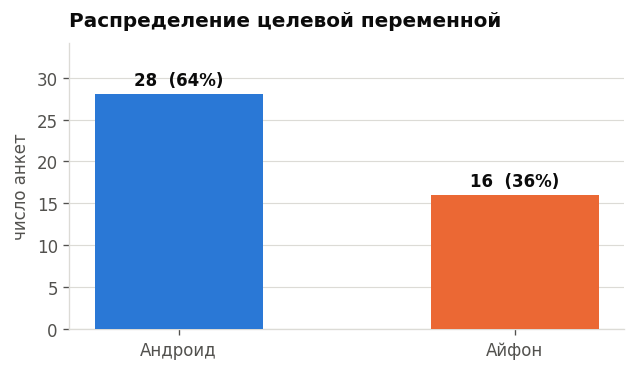

Преобладающий вариант (Android): 63.6%


In [8]:
counts = pd.Series(y).map({0: "Андроид", 1: "Айфон"}).value_counts()[["Андроид", "Айфон"]]

fig, ax = plt.subplots(figsize=(5.4, 3.2))
bars = ax.bar(counts.index, counts.values, width=0.5,
              color=[C_ANDROID, C_IPHONE], zorder=3)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v}  ({v / len(y):.0%})",
            ha="center", va="bottom", color=INK, fontweight="bold")
ax.set_title("Распределение целевой переменной")
ax.set_ylabel("число анкет")
ax.set_ylim(0, max(counts.values) * 1.22)
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"Преобладающий вариант (Android): {1 - y.mean():.1%}")

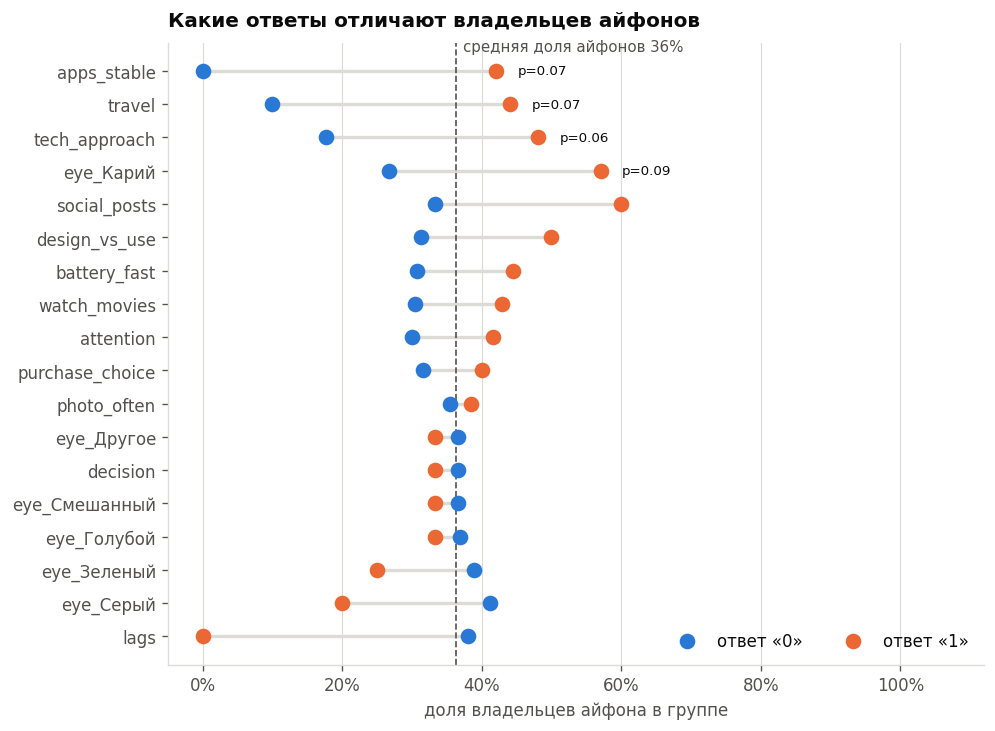

In [9]:
# Доля владельцев айфона внутри каждой группы ответов — где вообще есть сигнал?
rows = []
for c in BIN_FEATURES:
    m1, m0 = X[c] == 1, X[c] == 0
    if m1.sum() < 2 or m0.sum() < 2:
        continue
    table = pd.crosstab(X[c], y).reindex(index=[0, 1], columns=[0, 1]).fillna(0).values
    _, p = stats.fisher_exact(table)
    rows.append({"признак": c, "доля Айфон при 1": y[m1].mean(), "доля Айфон при 0": y[m0].mean(),
                 "n(1)": int(m1.sum()), "n(0)": int(m0.sum()), "p (Фишер)": p})
share = pd.DataFrame(rows)
share["разрыв"] = share["доля Айфон при 1"] - share["доля Айфон при 0"]
share = share.sort_values("разрыв")

fig, ax = plt.subplots(figsize=(8.4, 6.2))
ypos = np.arange(len(share))
ax.hlines(ypos, share["доля Айфон при 0"], share["доля Айфон при 1"], color=GRID, lw=2, zorder=1)
ax.scatter(share["доля Айфон при 0"], ypos, s=70, color=C_ANDROID, label="ответ «0»", zorder=3)
ax.scatter(share["доля Айфон при 1"], ypos, s=70, color=C_IPHONE, label="ответ «1»", zorder=3)
ax.axvline(y.mean(), color=INK2, ls="--", lw=1, zorder=2)
ax.text(y.mean() + 0.01, len(share) - 0.4, f"средняя доля айфонов {y.mean():.0%}",
        color=INK2, fontsize=9)
for i, (_, r) in enumerate(share.iterrows()):
    if r["p (Фишер)"] < 0.15:
        ax.text(max(r["доля Айфон при 1"], r["доля Айфон при 0"]) + 0.03, i,
                f"p={r['p (Фишер)']:.2f}", va="center", fontsize=8, color=INK)
ax.set_yticks(ypos, share["признак"])
ax.set_xlim(-0.05, 1.12)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_xlabel("доля владельцев айфона в группе")
ax.set_title("Какие ответы отличают владельцев айфонов")
ax.legend(loc="lower right", ncols=2)
ax.grid(axis="x"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

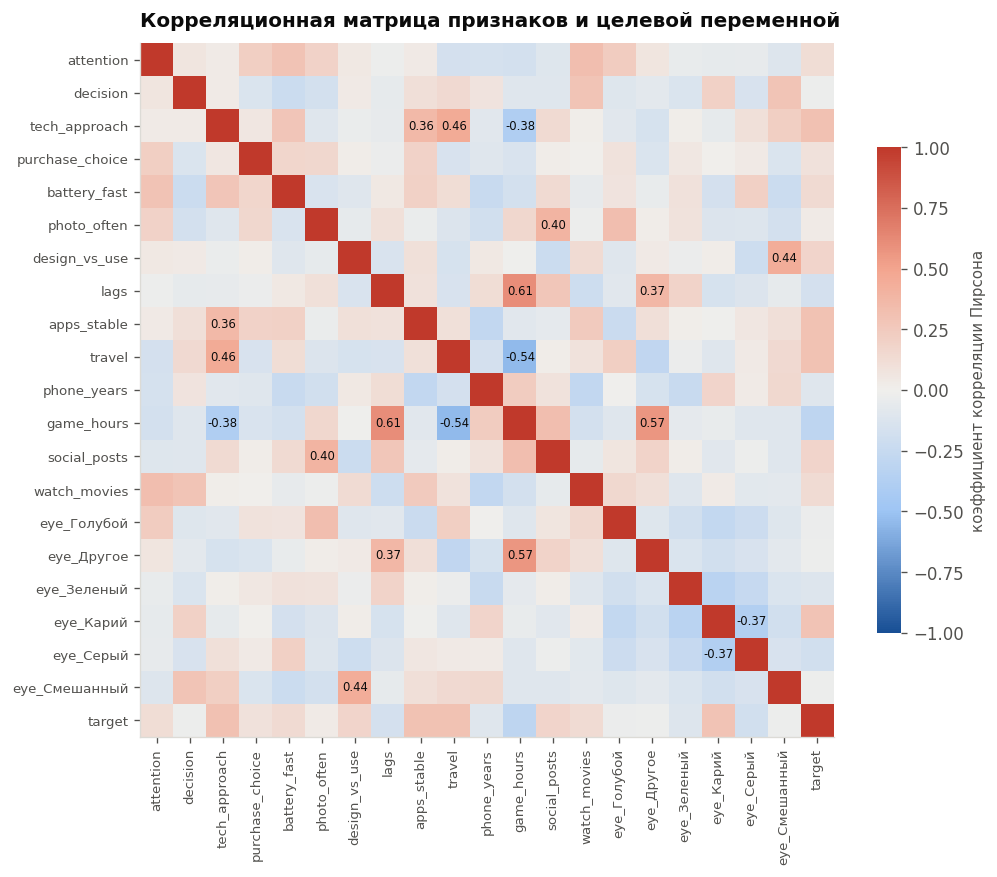

In [10]:
corr = X.assign(target=y).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8.6, 7.2))
im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.35 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.65 else INK)
ax.set_title("Корреляционная матрица признаков и целевой переменной")
cb = fig.colorbar(im, ax=ax, shrink=0.7); cb.outline.set_visible(False)
cb.set_label("коэффициент корреляции Пирсона", color=INK2, fontsize=9)
plt.tight_layout(); plt.show()

In [11]:
# Сводная таблица «сила связи признака с целевой переменной»
rows = []
for c in X.columns:
    r = np.corrcoef(X[c], y)[0, 1]
    if c in NUM_FEATURES:
        _, p = stats.pointbiserialr(y, X[c]); kind = "числовой"
    else:
        t = pd.crosstab(X[c], y).reindex(index=[0, 1], columns=[0, 1]).fillna(0).values
        _, p = stats.fisher_exact(t); kind = "бинарный"
    rows.append((c, kind, r, p))
signal = (pd.DataFrame(rows, columns=["признак", "тип", "корреляция с target", "p-value"])
            .sort_values("p-value").reset_index(drop=True))
signal.style.background_gradient(subset=["p-value"], cmap="Blues_r").format({"корреляция с target": "{:+.3f}", "p-value": "{:.3f}"})

,признак,тип,корреляция с target,p-value
0,game_hours,числовой,-0.298,0.049
1,tech_approach,бинарный,+0.309,0.057
2,travel,бинарный,+0.297,0.067
3,apps_stable,бинарный,+0.300,0.072
4,eye_Карий,бинарный,+0.295,0.091
5,eye_Серый,бинарный,-0.184,0.283
6,design_vs_use,бинарный,+0.174,0.303
7,social_posts,бинарный,+0.176,0.336
8,battery_fast,бинарный,+0.140,0.525
9,lags,бинарный,-0.165,0.526


**Выводы.** Связи слабые: ни один признак не проходит порог значимости 0.05 с запасом. Наиболее «говорящие»:

| признак | направление | p |
|---|---|---|
| `game_hours` | чем больше часов в играх, тем вероятнее **Андроид** | 0.049 |
| `tech_approach` | «чтобы всё работало из коробки» → **Айфон** | 0.057 |
| `travel` | любит путешествовать → **Айфон** | 0.067 |
| `apps_stable` | важна стабильность приложений → **Айфон** | 0.072 |
| `eye_Карий` | карие глаза → чуть чаще **Айфон** (скорее случайность на 44 анкетах) | 0.091 |


## 6. Разделение на обучение и тест

1. **Тестовая выборка** (25% ≈ 11 анкет) — очень шумная оценка: одна анкета меняет точность
2. **Обучение** (5 кусков × 20 повторов = 100 разбиений) — основной инструмент для подбора *k* и сравнения моделей: усреднение по 100 разбиениям резко снижает дисперсию оценки.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=RANDOM_STATE)

print(f"Обучение: {X_train.shape[0]} анкет (Айфон: {y_train.sum()}, Андроид: {(y_train == 0).sum()})")
print(f"Тест:     {X_test.shape[0]} анкет (Айфон: {y_test.sum()}, Андроид: {(y_test == 0).sum()})")
print(f"Схема кросс-валидации: {CV.get_n_splits()} разбиений")

Обучение: 33 анкет (Айфон: 12, Андроид: 21)
Тест:     11 анкет (Айфон: 4, Андроид: 7)
Схема кросс-валидации: 100 разбиений


## 7. Подбор *k* по кросс-валидации

### 7.1 Влияние масштабирования

k-NN основан на расстояниях, поэтому признак с большим разбросом доминирует. Здесь `game_hours` изменяется от 0 до 35, а бинарные признаки — от 0 до 1: без нормировки расстояние фактически считается по одному признаку «сколько часов в играх». Сравним четыре варианта предобработки на одной сетке *k*.

In [13]:
def make_pipe(pre, **knn_kwargs):
    return Pipeline([("pre", pre), ("knn", KNeighborsClassifier(**knn_kwargs))])

PREPROCESSORS = {
    "без масштабирования": "passthrough",
    "StandardScaler (все)": StandardScaler(),
    "MinMaxScaler (все)": MinMaxScaler(),
    "StandardScaler (только числовые)":
        ColumnTransformer([("num", StandardScaler(), NUM_FEATURES)], remainder="passthrough"),
}
K_GRID = list(range(1, 26))
SCORING = ["accuracy", "balanced_accuracy", "f1_macro", "roc_auc"]

records = []
for name, pre in PREPROCESSORS.items():
    for k in K_GRID:
        cvres = cross_validate(make_pipe(pre, n_neighbors=k), X_train, y_train, cv=CV,
                               scoring=SCORING, n_jobs=-1, return_train_score=True)
        records.append({
            "предобработка": name, "k": k,
            "accuracy": cvres["test_accuracy"].mean(), "acc_std": cvres["test_accuracy"].std(),
            "balanced_accuracy": cvres["test_balanced_accuracy"].mean(),
            "f1_macro": cvres["test_f1_macro"].mean(), "roc_auc": cvres["test_roc_auc"].mean(),
            "train_accuracy": cvres["train_accuracy"].mean(),
        })
cv_res = pd.DataFrame(records)
print("Готово: посчитано", len(cv_res), "конфигураций ×", CV.get_n_splits(), "разбиений")
cv_res.sort_values("accuracy", ascending=False).groupby("предобработка").head(1).sort_values("accuracy", ascending=False)

Готово: посчитано 100 конфигураций × 100 разбиений


,предобработка,k,accuracy,acc_std,balanced_accuracy,f1_macro,roc_auc,train_accuracy
83,StandardScaler (только числовые),9,0.698,0.144,0.617,0.583,0.685,0.740
61,MinMaxScaler (все),12,0.697,0.113,0.602,0.556,0.691,0.724
33,StandardScaler (все),9,0.679,0.140,0.585,0.543,0.647,0.738
1,без масштабирования,2,0.653,0.130,0.547,0.482,0.530,0.762


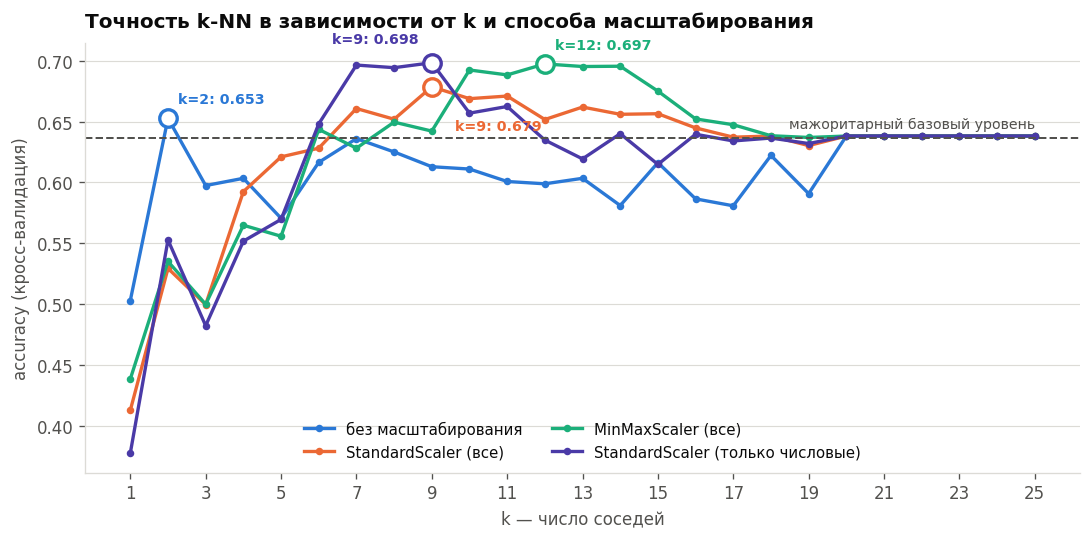

In [14]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
colors = [C_ANDROID, C_IPHONE, C_AQUA, C_VIOLET]
offsets = [(6, 9), (14, -26), (6, 9), (-8, 12)]
for i, ((name, grp), color) in enumerate(zip(cv_res.groupby("предобработка", sort=False), colors)):
    ax.plot(grp["k"], grp["accuracy"], color=color, label=name, marker="o", ms=3.5)
    best = grp.loc[grp["accuracy"].idxmax()]
    ax.scatter([best["k"]], [best["accuracy"]], s=110, facecolor="white",
               edgecolor=color, linewidth=2, zorder=5)
    ax.annotate(f"k={int(best['k'])}: {best['accuracy']:.3f}",
                (best["k"], best["accuracy"]), textcoords="offset points",
                xytext=offsets[i], color=color, fontsize=8.5, fontweight="bold",
                ha="right" if i == 3 else "left", zorder=6)
ax.axhline(1 - y_train.mean(), color=INK2, ls="--", lw=1.2)
ax.text(K_GRID[-1], 1 - y_train.mean() + 0.008, "мажоритарный базовый уровень",
        ha="right", color=INK2, fontsize=8.5)
ax.set_xlabel("k — число соседей"); ax.set_ylabel("accuracy (кросс-валидация)")
ax.set_title("Точность k-NN в зависимости от k и способа масштабирования")
ax.set_xticks(K_GRID[::2]); ax.grid(axis="y"); ax.set_axisbelow(True)
ax.legend(loc="lower center", ncols=2, fontsize=9)
plt.tight_layout(); plt.show()

### 7.2 Переобучение при малых *k* и вырождение при больших

При $k=1$ модель идеально помнит обучающую выборку (train accuracy = 1.0), но на новых данных работает хуже всего — классическое переобучение и высокая дисперсия. При $k \to n$ все объекты попадают в «соседи», и модель вырождается в константный ответ «мажоритарный класс» — высокое смещение. Оптимум посередине.

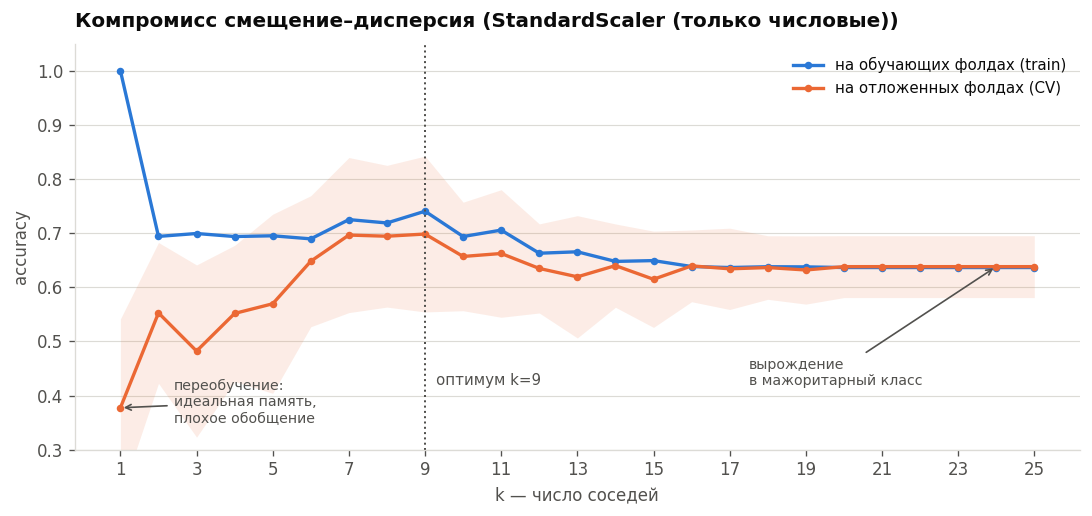

In [15]:
best_pre_name = cv_res.loc[cv_res["accuracy"].idxmax(), "предобработка"]
sub = cv_res[cv_res["предобработка"] == best_pre_name]

fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(sub["k"], sub["train_accuracy"], color=C_ANDROID, marker="o", ms=3.5,
        label="на обучающих фолдах (train)")
ax.plot(sub["k"], sub["accuracy"], color=C_IPHONE, marker="o", ms=3.5,
        label="на отложенных фолдах (CV)")
ax.fill_between(sub["k"], sub["accuracy"] - sub["acc_std"], sub["accuracy"] + sub["acc_std"],
                color=C_IPHONE, alpha=0.12, lw=0)
kb = int(sub.loc[sub["accuracy"].idxmax(), "k"])
ax.axvline(kb, color=INK2, ls=":", lw=1.2)
ax.text(kb + 0.3, 0.42, f"оптимум k={kb}", color=INK2, fontsize=9)
ax.annotate("переобучение:\nидеальная память,\nплохое обобщение", xy=(1, sub["accuracy"].iloc[0]),
            xytext=(2.4, 0.35), fontsize=8.5, color=INK2,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
ax.annotate("вырождение\nв мажоритарный класс", xy=(24, sub["accuracy"].iloc[-1]),
            xytext=(17.5, 0.42), fontsize=8.5, color=INK2,
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
ax.set_xlabel("k — число соседей"); ax.set_ylabel("accuracy")
ax.set_title(f"Компромисс смещение–дисперсия ({best_pre_name})")
ax.set_xticks(K_GRID[::2]); ax.set_ylim(0.3, 1.05)
ax.grid(axis="y"); ax.set_axisbelow(True); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

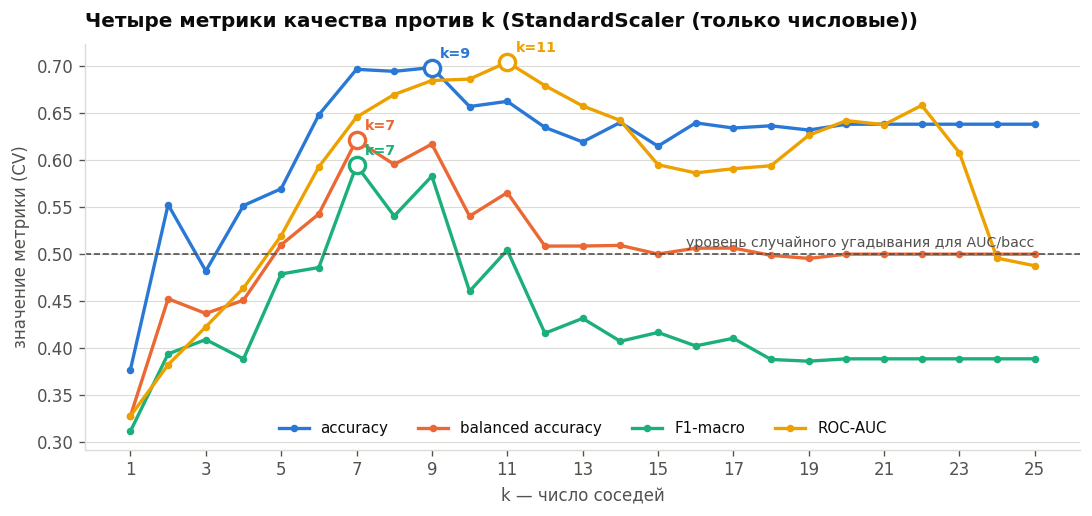

In [16]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))
for metric, color, label in [("accuracy", C_ANDROID, "accuracy"),
                             ("balanced_accuracy", C_IPHONE, "balanced accuracy"),
                             ("f1_macro", C_AQUA, "F1-macro"),
                             ("roc_auc", C_YELLOW, "ROC-AUC")]:
    ax.plot(sub["k"], sub[metric], color=color, marker="o", ms=3.5, label=label)
    best = sub.loc[sub[metric].idxmax()]
    ax.scatter([best["k"]], [best[metric]], s=95, facecolor="white", edgecolor=color, lw=2, zorder=5)
    ax.annotate(f"k={int(best['k'])}", (best["k"], best[metric]), textcoords="offset points",
                xytext=(5, 6), fontsize=8.5, color=color, fontweight="bold")
ax.axhline(0.5, color=INK2, ls="--", lw=1)
ax.text(K_GRID[-1], 0.508, "уровень случайного угадывания для AUC/bacc", ha="right",
        color=INK2, fontsize=8.5)
ax.set_xlabel("k — число соседей"); ax.set_ylabel("значение метрики (CV)")
ax.set_title(f"Четыре метрики качества против k ({best_pre_name})")
ax.set_xticks(K_GRID[::2]); ax.grid(axis="y"); ax.set_axisbelow(True)
ax.legend(ncols=4, loc="lower center", fontsize=9)
plt.tight_layout(); plt.show()

In [17]:
top = (sub.sort_values("accuracy", ascending=False)
          .head(10)[["k", "accuracy", "acc_std", "balanced_accuracy", "f1_macro", "roc_auc", "train_accuracy"]]
          .reset_index(drop=True))
print(f"Лучшие 10 значений k для «{best_pre_name}» (по accuracy на 100 разбиениях):")
top.style.background_gradient(subset=["accuracy", "balanced_accuracy", "f1_macro", "roc_auc"], cmap="Blues").format("{:.3f}", subset=top.columns[1:])

Лучшие 10 значений k для «StandardScaler (только числовые)» (по accuracy на 100 разбиениях):


,k,accuracy,acc_std,balanced_accuracy,f1_macro,roc_auc,train_accuracy
0,9,0.698,0.144,0.617,0.583,0.685,0.740
1,7,0.696,0.143,0.621,0.594,0.646,0.725
2,8,0.694,0.131,0.595,0.541,0.670,0.719
3,11,0.662,0.118,0.565,0.504,0.704,0.706
4,10,0.657,0.100,0.540,0.461,0.686,0.694
5,6,0.648,0.121,0.543,0.486,0.593,0.689
6,14,0.640,0.077,0.509,0.407,0.642,0.648
7,16,0.640,0.066,0.506,0.403,0.586,0.638
8,20,0.638,0.057,0.500,0.389,0.642,0.636
9,21,0.638,0.057,0.500,0.389,0.638,0.636


## 8. Оценка итоговой модели

### 8.1 Полный перебор гиперпараметров (GridSearchCV)

В разделе 7 перебиралось только *k* при настройках по умолчанию. Теперь перебираем всё сразу:
предобработка × *k* × схема весов × метрика расстояния — 300 конфигураций, каждая оценивается
на 50 разбиениях (5 фолдов × 10 повторов).

In [18]:
param_grid = {
    "pre": [StandardScaler(), MinMaxScaler(), "passthrough"],
    "knn__n_neighbors": K_GRID,
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}
GRID_CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
grid = GridSearchCV(
    Pipeline([("pre", StandardScaler()), ("knn", KNeighborsClassifier())]),
    param_grid, cv=GRID_CV, scoring="accuracy", n_jobs=-1, return_train_score=True,
)
grid.fit(X_train, y_train)

print("Лучшие параметры:")
for key, val in grid.best_params_.items():
    print(f"   {key:22s} = {val}")
print(f"\nЛучшая CV-точность: {grid.best_score_:.3f}")

gr = pd.DataFrame(grid.cv_results_)
gr["предобработка"] = gr["param_pre"].astype(str).str.replace(r"\(\)", "", regex=True)
(gr.sort_values("rank_test_score")
   .head(12)[["param_knn__n_neighbors", "param_knn__weights", "param_knn__p",
              "предобработка", "mean_test_score", "std_test_score"]]
   .rename(columns={"param_knn__n_neighbors": "k", "param_knn__weights": "веса",
                    "param_knn__p": "p", "mean_test_score": "CV accuracy",
                    "std_test_score": "std"}).reset_index(drop=True))

Лучшие параметры:
   knn__n_neighbors       = 11
   knn__p                 = 2
   knn__weights           = distance
   pre                    = MinMaxScaler()

Лучшая CV-точность: 0.724


,k,веса,p,предобработка,CV accuracy,std
0,11,distance,2,MinMaxScaler,0.724,0.140
1,11,uniform,2,MinMaxScaler,0.715,0.146
2,10,uniform,1,MinMaxScaler,0.713,0.127
3,11,uniform,1,MinMaxScaler,0.712,0.157
4,12,uniform,2,MinMaxScaler,0.712,0.117
5,12,uniform,1,MinMaxScaler,0.712,0.117
6,10,uniform,2,MinMaxScaler,0.710,0.125
7,13,distance,2,MinMaxScaler,0.708,0.130
8,14,uniform,1,MinMaxScaler,0.700,0.112
9,14,uniform,2,MinMaxScaler,0.700,0.112


### 8.2 Качество на отложенном тесте

Берём лучшую по кросс-валидации конфигурацию, обучаем на обучающей выборке и проверяем на тестовой.

In [19]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics_test = pd.Series({
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced accuracy": balanced_accuracy_score(y_test, y_pred),
    "F1 (Айфон)": f1_score(y_test, y_pred),
    "F1-macro": f1_score(y_test, y_pred, average="macro"),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}, name="отложенный тест")
print(metrics_test.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nОтчёт по классам:\n")
print(classification_report(y_test, y_pred, target_names=["Андроид", "Айфон"], digits=3))

accuracy            0.636
balanced accuracy   0.607
F1 (Айфон)          0.500
F1-macro            0.607
ROC-AUC             0.571

Отчёт по классам:

              precision    recall  f1-score   support

     Андроид      0.714     0.714     0.714         7
       Айфон      0.500     0.500     0.500         4

    accuracy                          0.636        11
   macro avg      0.607     0.607     0.607        11
weighted avg      0.636     0.636     0.636        11



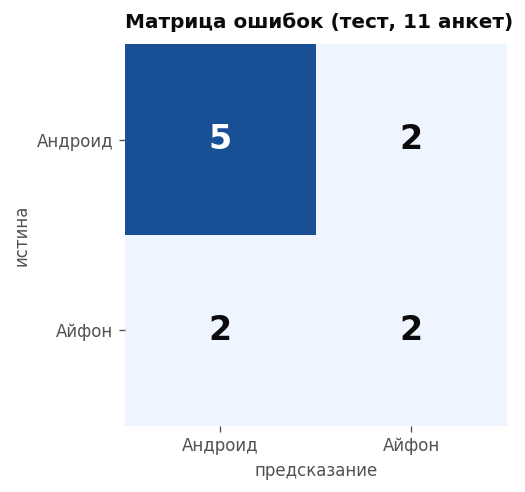

In [20]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap=SEQ_BLUE)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=20, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.6 else INK)
ax.set_xticks([0, 1], ["Андроид", "Айфон"]); ax.set_yticks([0, 1], ["Андроид", "Айфон"])
ax.set_xlabel("предсказание"); ax.set_ylabel("истина")
ax.set_title("Матрица ошибок (тест, 11 анкет)")
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout(); plt.show()

In [21]:
# Более устойчивая оценка той же конфигурации — на всех 44 анкетах, 100 разбиений
final_cv = cross_validate(best_model, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
summary = pd.DataFrame({
    "среднее": [final_cv[f"test_{m}"].mean() for m in SCORING],
    "ст. отклонение": [final_cv[f"test_{m}"].std() for m in SCORING],
    "95% интервал (±)": [1.96 * final_cv[f"test_{m}"].std() for m in SCORING],
}, index=["accuracy", "balanced accuracy", "F1-macro", "ROC-AUC"])
print("Повторная кросс-валидация итоговой модели на всей выборке (5×20):")
summary

Повторная кросс-валидация итоговой модели на всей выборке (5×20):


,среднее,ст. отклонение,95% интервал (±)
accuracy,0.636,0.120,0.236
balanced accuracy,0.554,0.138,0.270
F1-macro,0.525,0.161,0.316
ROC-AUC,0.566,0.185,0.362


## 9. Сравнение с другими моделями

Сам по себе показатель точности мало что значит: нужно сравнение с «глупым» базовым решением (всегда отвечать «Андроид») и с несколькими стандартными классификаторами. Все модели оцениваются одинаково — 5×20 кросс-валидация на всех данных.

In [22]:
knn_params = {k.split("__")[1]: v for k, v in grid.best_params_.items() if k.startswith("knn__")}
best_pre = grid.best_params_["pre"]

models = {
    "Мажоритарный класс (baseline)": DummyClassifier(strategy="most_frequent"),
    "Случайный выбор (стратиф.)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    f"k-NN (k={knn_params['n_neighbors']}, подобранный)": Pipeline([("pre", best_pre), ("knn", KNeighborsClassifier(**knn_params))]),
    "k-NN (k=1)": Pipeline([("pre", MinMaxScaler()), ("knn", KNeighborsClassifier(n_neighbors=1))]),
    "Логистическая регрессия": Pipeline([("pre", StandardScaler()), ("m", LogisticRegression(max_iter=1000))]),
    "Дерево решений (depth=3)": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Случайный лес": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Наивный Байес": GaussianNB(),
}

rows = []
for name, model in models.items():
    r = cross_validate(model, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    rows.append({"модель": name,
                 "accuracy": r["test_accuracy"].mean(), "±": r["test_accuracy"].std(),
                 "balanced accuracy": r["test_balanced_accuracy"].mean(),
                 "F1-macro": r["test_f1_macro"].mean(),
                 "ROC-AUC": r["test_roc_auc"].mean()})
comparison = pd.DataFrame(rows).sort_values("balanced accuracy", ascending=False).reset_index(drop=True)
comparison.style.background_gradient(subset=["accuracy", "balanced accuracy", "F1-macro", "ROC-AUC"], cmap="Blues").format("{:.3f}", subset=comparison.columns[1:])

,модель,accuracy,±,balanced accuracy,F1-macro,ROC-AUC
0,Случайный лес,0.629,0.128,0.577,0.565,0.621
1,Наивный Байес,0.538,0.135,0.577,0.521,0.580
2,Дерево решений (depth=3),0.596,0.143,0.573,0.551,0.616
3,"k-NN (k=11, подобранный)",0.636,0.120,0.554,0.525,0.566
4,Логистическая регрессия,0.593,0.140,0.552,0.538,0.604
5,Случайный выбор (стратиф.),0.549,0.151,0.506,0.505,0.506
6,Мажоритарный класс (baseline),0.636,0.043,0.500,0.388,0.500
7,k-NN (k=1),0.467,0.134,0.420,0.404,0.420


## 10. Пример предсказания для нового респондента

Покажем модель «в работе»: заполним анкету за вымышленного человека и посмотрим не только ответ, но и **кто именно из обучающей выборки стал его соседями** — в этом главное достоинство k-NN, его предсказание всегда можно объяснить.

In [ ]:
def make_respondent(**answers):
    """Собирает вектор признаков в том же порядке, что и обучающая матрица."""
    row = pd.Series(0.0, index=X.columns)
    for key, val in answers.items():
        if key == "eye_color":
            col = f"eye_{val}"
            assert col in row.index, f"неизвестный цвет глаз: {val}"
            row[col] = 1.0
        else:
            row[key] = float(val)
    return row.to_frame().T

# "Мажорный" профиль: важен дизайн, покупает популярное, почти не играет
new_person = make_respondent(
    attention=1, decision=0, tech_approach=1, purchase_choice=1, battery_fast=1,
    photo_often=1, design_vs_use=1, lags=0, apps_stable=1, travel=1,
    phone_years=3, game_hours=1, social_posts=1, watch_movies=1, eye_color="Карий",
)

proba = best_model.predict_proba(new_person)[0]
pred = best_model.predict(new_person)[0]
print(f"Предсказание: {'Айфон' if pred == 1 else 'Андроид'}")
print(f"Вероятности: Андроид {proba[0]:.2f} | Айфон {proba[1]:.2f}\n")

pre_fitted = best_model.named_steps["pre"]
dist, idx = best_model.named_steps["knn"].kneighbors(
    pre_fitted.transform(new_person), n_neighbors=knn_params["n_neighbors"])
votes = y_train[idx[0]]
w = 1.0 / np.maximum(dist[0], 1e-12)

neighbors = pd.DataFrame({
    "строка исходной таблицы": X_train.index[idx[0]],
    "расстояние": dist[0],
    "вес 1/d": w,
    "его телефон": np.where(votes == 1, "Айфон", "Андроид"),
    "лет до замены": X_train.iloc[idx[0]]["phone_years"].values,
    "часов в играх": X_train.iloc[idx[0]]["game_hours"].values,
})
print(f"{knn_params['n_neighbors']} ближайших соседей: "
      f"{int(votes.sum())} за Айфон, {int((votes == 0).sum())} за Андроид")
print(f"Взвешенная доля голосов за Айфон: {w[votes == 1].sum() / w.sum():.2f} "
      f"(это и есть вероятность из predict_proba)")
neighbors

Предсказание: Айфон
Вероятности: Андроид 0.27 | Айфон 0.73

11 ближайших соседей: 8 за Айфон, 3 за Андроид
Взвешенная доля голосов за Айфон: 0.73 (это и есть вероятность из predict_proba)


,строка исходной таблицы,расстояние,вес 1/d,его телефон,лет до замены,часов в играх
0,1,1.414,0.707,Айфон,3.000,1.000
1,2,1.732,0.577,Айфон,3.000,1.000
2,13,1.741,0.574,Андроид,2.000,7.000
3,40,2.028,0.493,Айфон,5.000,0.000
4,8,2.236,0.447,Андроид,3.000,0.000
5,16,2.243,0.446,Айфон,4.000,10.000
6,25,2.261,0.442,Айфон,5.000,0.000
7,5,2.261,0.442,Андроид,5.000,8.000
8,7,2.450,0.408,Айфон,3.000,5.000
9,39,2.455,0.407,Айфон,2.000,1.000


## 11. Ответы на вопросы и выводы

In [24]:
best_k = knn_params["n_neighbors"]
baseline_acc = 1 - y.mean()
knn_row = comparison[comparison["модель"].str.contains("подобранный")].iloc[0]
base_row = comparison[comparison["модель"].str.contains("baseline")].iloc[0]
k1_row = comparison[comparison["модель"] == "k-NN (k=1)"].iloc[0]

print("=" * 72)
print("КЛЮЧЕВЫЕ ЧИСЛА ОТЧЁТА")
print("=" * 72)
print(f"Объём выборки                 : {X.shape[0]} анкет, {X.shape[1]} признаков после кодирования")
print(f"Баланс классов                : Андроид {(y==0).sum()} / Айфон {y.sum()}  (базовый уровень {baseline_acc:.1%})")
print("-" * 72)
print(f"ЛУЧШЕЕ k                      : {best_k}")
print(f"  метрика расстояния          : p = {knn_params['p']} "
      f"({'манхэттенская' if knn_params['p'] == 1 else 'евклидова'})")
print(f"  веса соседей                : {knn_params['weights']}")
print(f"  предобработка               : {type(best_pre).__name__ if best_pre != 'passthrough' else 'без масштабирования'}")
print(f"  CV-точность при подборе     : {grid.best_score_:.3f}")
print("-" * 72)
print(f"Отложенный тест (11 анкет)    : accuracy {metrics_test['accuracy']:.3f}, "
      f"bacc {metrics_test['balanced accuracy']:.3f}, AUC {metrics_test['ROC-AUC']:.3f}")
print(f"Кросс-валидация на всех данных: accuracy {knn_row['accuracy']:.3f}, "
      f"bacc {knn_row['balanced accuracy']:.3f}, F1-macro {knn_row['F1-macro']:.3f}")
print(f"Мажоритарный baseline         : accuracy {base_row['accuracy']:.3f}, "
      f"bacc {base_row['balanced accuracy']:.3f}, F1-macro {base_row['F1-macro']:.3f}")
print(f"k-NN при k=1 (переобучение)   : accuracy {k1_row['accuracy']:.3f}, "
      f"bacc {k1_row['balanced accuracy']:.3f}")
print("-" * 72)
print("Самые информативные признаки  : " + ", ".join(signal.head(4)["признак"]))
print("=" * 72)

КЛЮЧЕВЫЕ ЧИСЛА ОТЧЁТА
Объём выборки                 : 44 анкет, 20 признаков после кодирования
Баланс классов                : Андроид 28 / Айфон 16  (базовый уровень 63.6%)
------------------------------------------------------------------------
ЛУЧШЕЕ k                      : 11
  метрика расстояния          : p = 2 (евклидова)
  веса соседей                : distance
  предобработка               : MinMaxScaler
  CV-точность при подборе     : 0.724
------------------------------------------------------------------------
Отложенный тест (11 анкет)    : accuracy 0.636, bacc 0.607, AUC 0.571
Кросс-валидация на всех данных: accuracy 0.636, bacc 0.554, F1-macro 0.525
Мажоритарный baseline         : accuracy 0.636, bacc 0.500, F1-macro 0.388
k-NN при k=1 (переобучение)   : accuracy 0.467, bacc 0.420
------------------------------------------------------------------------
Самые информативные признаки  : game_hours, tech_approach, travel, apps_stable


### 11.1 Какое *k* лучше?

Лучшее k = 11 (евклидова метрика $p=2$, веса `distance`, признаки отмасштабированы `MinMaxScaler`) — это максимум CV-точности 0.724 на сетке из 300 конфигураций × 50 разбиений.

Важная оговорка: оптимум не точечный, а пологий. Значения *k* от 9 до 13 дают 0.70–0.72, что при стандартном отклонении по фолдам ≈ 0.14 статистически неразличимо. Правильный ответ поэтому звучит так: хорошее k лежит в диапазоне 9–13, и в качестве рабочего значения выбрано k = 11. 

### 11.2 Нужна ли нормировка признаков?

Да, это самый значимый фактор после k. Лучшие результаты по каждому варианту предобработки:

| предобработка | лучшее k | accuracy (CV) |
|---|---|---|
| StandardScaler (только числовые) | 9 | **0.698** |
| MinMaxScaler (все признаки) | 12 | 0.697 |
| StandardScaler (все признаки) | 9 | 0.679 |
| без масштабирования | 2 | 0.653 |

Причина в природе метода: расстояние складывается из вкладов всех признаков, а `game_hours` меняется от 0 до 35 при бинарных признаках в диапазоне 0–1. Без нормировки одна разница в 10 часов игр даёт вклад в квадрат расстояния в 100 раз больше, чем полное несовпадение по любому вопросу анкеты.

### 11.3 Насколько хороша итоговая модель?

| оценка | accuracy | balanced accuracy | F1-macro | ROC-AUC |
|---|---|---|---|---|
| k-NN на отложенном тесте (11 анкет) | 0.636 | 0.607 | 0.607 | 0.571 |
| k-NN, кросс-валидация 5×20 на всех данных | 0.636 | 0.554 | 0.525 | 0.566 |
| «всегда Андроид» (baseline) | 0.636 | 0.500 | 0.388 | — |
| k-NN при k = 1 | 0.467 | 0.420 | 0.318 | — |

Вывод: модель работает, но слабо. По точности она на уровне базового решения (0.636), и лишь по сбалансированным метрикам заметно его превосходит (bacc 0.554 против 0.500, F1-macro 0.525 против 0.388) — то есть, в отличие от baseline, она всё-таки иногда правильно находит владельцев айфонов, а не игнорирует меньший класс

Прочие модели (логистическая регрессия, дерево, случайный лес, наивный Байес) ведут себя так же — все в коридоре bacc 0.54–0.58. Получается, дело не в выборе алгоритма, а в данных.

### 11.4 Почему качество невысокое и что с этим делать

1. Мало данных - 44 анкеты на 20 признаков — примерно 2 объекта на измерение. k-NN особенно чувствителен к этому: в 20-мерном пространстве расстояния между всеми точками становятся почти одинаковыми («проклятие размерности»), и понятие «ближайший сосед» теряет смысл.
2. Вопросы слабо связаны с целью - большинство вопросов анкеты (центр внимания, путешествия, цвет глаз, станция метро) не имеют отношения к выбору платформы.
3. Дисбаланс классов - большинство ответов «Андроид».